In [1]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', as_frame=False)

In [2]:
X, y = mnist.data, mnist.target
print("x:", X)
print("y", y)
print(X.shape, "\n")
print(y.shape)

x: [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
y ['5' '0' '4' ... '4' '5' '6']
(70000, 784) 

(70000,)


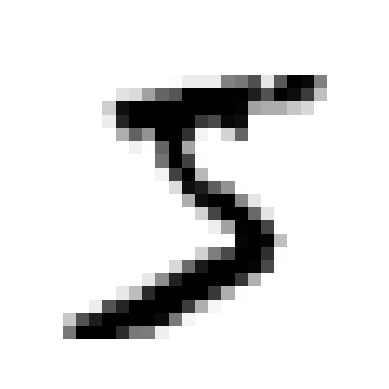

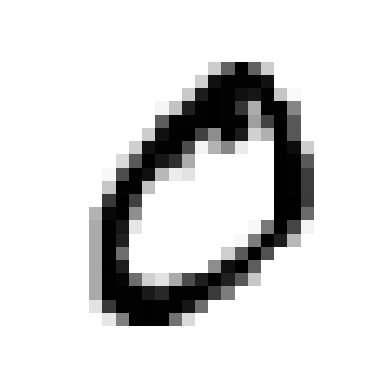

[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255
 247 127   0   0   0   0   0   0   0   0   0   0   0   0  30  36  94 154
 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0   0   0
   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82
  82  56  39   0   0   0   0   0   0   0   0   0   0   0   0  18 219 253
 253 253 253 253 198 182 247 241   0   0   0   0   

In [ ]:
# Take a look on data
import matplotlib.pyplot as plt


def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary") # cmap="binary" to get a grayscale color map
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
plt.show()
# where 0 is white and 255 is black
print(X[0])
# It's looks like a five, if we take a look on "y" we see a 5
print(y[0])

In [4]:
# Training and test set (it's already is splitted and shuffled)
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]
# 70 000 всего 60 000 train, 10 000 test

In [5]:
from sklearn.linear_model import SGDClassifier

# Training a Binary Classifier

# [True, False, False, True, False] boolean mask
# Тут создатся массив по длине как y_train но со значениями True или False
# то есть там где равно 5 будет true, в других местах false
y_train_5 = y_train == "5"  # True for all 5s, False for all other digits
y_test_5 = y_test == "5"

# Мы даем фичи и лейблы чтобы SGDClassifier мог определять
# Исходя из лейблов к фичам что будет означать тот или иной ответ
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)
# X0 =5, X1 = 0
sgd_clf.predict([X[0], X[1]])


array([ True, False])

## Performance Measures

In [ ]:
# Measuring Accuracy Using Cross-Validation
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")
# Точность 95%

array([0.95035, 0.96035, 0.9604 ])

In [ ]:
from sklearn.dummy import DummyClassifier

# DummyClassifier предсказывает самый частый класс. 
# True  = цифра 5
# False = не 5
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
# any(...) проверяет Есть ли хотя бы один True?
print(any(dummy_clf.predict(X_train)))
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")
# over 90%
# Можно иметь высокую accuracy,
# даже если модель вообще никогда не находит пятёрки.
# because only about 10% of the images are 5s
# This demonstrates why accuracy is generally not the preferred 
# performance measure for classifiers

# A much better way to evaluate the
# performance of a classifier is to look at the confusion matrix (CM).

False


array([0.90965, 0.90965, 0.90965])

In [ ]:
# IMPLEMENTING CROSS-VALIDATION

# custom cross validation, make same thing like Scikit-Learn 

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone 

skflods = StratifiedKFold(n_splits=3) # add shuffle=True if the dataset is not already shuffled
# делим на 3 части и сохраняем одинаковое соотношение классов
# 10% = True (5) ; 90% = False (не 5)

for train_index, test_index in skflods.split(X_train, y_train_5):
	clone_clf = clone(sgd_clf) 	# new empty model exact params, weights not copied 
	X_train_folds = X_train[train_index]
	y_train_folds = y_train_5[train_index]
	X_test_fold = X_train[test_index]
	y_test_fold = y_train_5[test_index]

	clone_clf.fit(X_train_folds, y_train_folds) # only on train
	y_pred = clone_clf.predict(X_test_fold) # predict on test fold
	n_correct = sum(y_pred == y_test_fold)
	print(n_correct / len(y_pred))

0.95035
0.96035
0.9604


In [6]:
# Confusion Matrices
from sklearn.metrics import confusion_matrix
# cross_val_predict генерирует предсказания для каждого объекта так, 
# будто модель этот объект раньше не видела.
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)
cm = confusion_matrix(y_train_5, y_train_pred)
print(cm)

# [0][0] = 53892 True Negative (TN)
# реально был 0 (это не 5),
# и модель тоже предсказала 0 (это не 5)

# [0][1] = 687 False Positive (FP)
# реально был 0 (это не 5),
# но модель ошибочно предсказала 1 (это 5)

# [1][0] = 1891 False Negative (FN)
# реально был 1 (это 5),
# но модель ошибочно предсказала 0 (это не 5)

# [1][1] = 3530 True Positive (TP)
# реально был 1 (это 5),
# и модель правильно предсказала 1 (это 5)

# perfect classifier 
y_train_perfect_predictions = y_train_5
cm_perfect = confusion_matrix(y_train_5, y_train_perfect_predictions)
print(cm_perfect)

[[53892   687]
 [ 1891  3530]]
[[54579     0]
 [    0  5421]]


In [ ]:
# Confusion Matrices example
from sklearn.metrics import confusion_matrix

y_true_example = [0, 0, 1, 1, 1, 0]
y_pred_example = [0, 1, 1, 0, 1, 0]

cm = confusion_matrix(y_true_example, y_pred_example)
print(cm)

#                  predicted
#                  0     1
# actual is 0      ?     ?
# actual is 1      ?     ?

#               predicted
#               0               1
# actual 0      True Negative   False Positive
# actual 1      False Negative  True Positive

# [0][0] = 2
# True Negative (TN)
# реально был negative class (0)
# модель правильно предсказала negative class (0)

# [0][1] = 1
# False Positive (FP)
# реально был negative class (0)
# модель ошибочно предсказала positive class (1)

# [1][0] = 1
# False Negative (FN)
# реально был positive class (1)
# модель ошибочно предсказала negative class (0)

# [1][1] = 2
# True Positive (TP)
# реально был positive class (1)
# модель правильно предсказала positive class (1)

[[2 1]
 [1 2]]


Confusion matrix даёт много информации, но иногда удобнее использовать более краткую метрику.

Одна из таких метрик — **precision** (точность положительных предсказаний).

Формула:

Precision = TP / (TP + FP)

Где:
- TP (True Positive) — реально был positive class и модель правильно сказала positive
- FP (False Positive) — реально был negative class, но модель ошибочно сказала positive

Наш confusion matrix:

[[53892, 687],
 [1891, 3530]]

Значит:

TP = 3530  
FP = 687

Подставляем:

Precision = 3530 / (3530 + 687)
Precision ≈ 0.837

Или:

Precision ≈ 83.7%

Простыми словами:

Когда модель говорит "это 5", она права примерно в 83.7% случаев.

Но precision имеет проблему:
он НЕ учитывает False Negative (FN) —
случаи, когда реально была 5, но модель сказала "не 5".

Из-за этого precision может быть высоким даже у плохой модели.

Например:
- есть 100 настоящих пятёрок
- модель нашла только 1
- но угадала её правильно

Тогда:

TP = 1
FP = 0

Precision = 1 / (1 + 0) = 100%

Но модель плохая, потому что она пропустила остальные 99 пятёрок.

---

Поэтому precision обычно используют вместе с другой метрикой — **recall**.

Recall показывает:

"из всех настоящих positive объектов сколько модель смогла найти"

Формула:

Recall = TP / (TP + FN)

Где:
- TP (True Positive) — реально positive и модель правильно сказала positive
- FN (False Negative) — реально positive, но модель ошибочно сказала negative

Для нашего confusion matrix:

TP = 3530  
FN = 1891

Подставляем:

Recall = 3530 / (3530 + 1891)
Recall ≈ 0.651

Или:

Recall ≈ 65.1%

Простыми словами:

Модель смогла найти примерно 65.1% всех настоящих пятёрок.

In [9]:
# Precision and Recall
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score

# Precision = TP / (TP + FP) насколько чисто предсказывает
print(precision_score(y_train_5, y_train_pred)) # == 3530 / (687 + 3530)

# Recall = TP / (TP + FN) насколько много объектов она находит
print(recall_score(y_train_5, y_train_pred)) # == 3530 / (1891 + 3530)

# Объединенная метрика с этими двумя
# это гармоническое среднее precision и recall (Модель хорошая только если ОБЕ метрики хорошие.)
print(f1_score(y_train_5, y_train_pred))

# | Precision | Recall | F1      |
# | --------- | ------ | ------- |
# | 0.90      | 0.90   | высокий |
# | 0.90      | 0.20   | низкий  |
# | 0.50      | 0.50   | средний |


0.8370879772350012
0.6511713705958311
0.7325171197343847


## Формула F1

$$
F_1 = 2 \times \frac{\text{precision} \times \text{recall}}{\text{precision} + \text{recall}}
$$

High recall модель

Будет:
много найденных 5
мало пропущенных 5
но много ложных срабатываний
Low recall модель

Будет:
осторожной
редко говорить «это 5»
зато пропускать реальные пятёрки


Recall = «не пропускать»

Представь сеть для рыбы.

High recall:
сеть ловит почти всю рыбу
но вместе с мусором
High precision:
сеть ловит только хорошую рыбу
но часть рыбы уплывает

Scores for 5 [2164.22030239]
Scores for 0 [-5897.37359354]
It's five? [ True]
It's five? [False]
[  1200.93051237 -26883.79202424 -33072.03475406 ...  13272.12718981
  -7258.47203373 -16877.50840447]


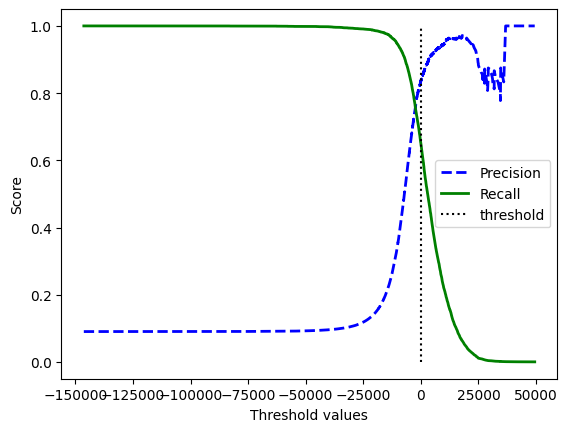

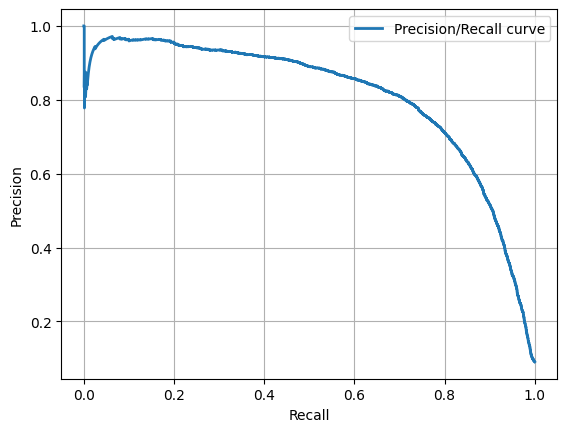

In [7]:
# The Precision/Recall Trade-off
# Повышение recall уменьшает количество пропущенных
# positive-объектов (FN), но обычно увеличивает число ложных срабатываний
# (FP), из-за чего падает precision. Повышение precision уменьшает количество
# ложных  positive-предсказаний, но модель становится строже и начинает
# пропускать больше настоящих positive-объектов, снижая recall.
# (по книге мы крутим threshold меняя эти Precision/Recall)
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# X0 = 5, X1 = 0
scores_for_five = sgd_clf.decision_function([X[0]])
scores_for_not_five = sgd_clf.decision_function([X[1]])
print("Scores for 5", scores_for_five)  # сильный positive
print("Scores for 0", scores_for_not_five)  # сильный negative
threshold = 0
print("It's five?", scores_for_five > threshold)
print("It's five?", scores_for_not_five > threshold)
# SGDClassifier uses a threshold equal to 0

# Возврат scores вместо predictions
y_scores = cross_val_predict(
    sgd_clf, X_train, y_train_5, cv=3, method="decision_function"
)
print(y_scores)

# y_true реальные ответы
# y_scores scores модели
# и вычисляет: precision,recall для множества разных threshold.
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

# Визуально отобразим (график thresholds относительно precisions и recalls)
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")
plt.xlabel("Threshold values") # возможные пороги для decision_function score
plt.ylabel("Score") # значения precision и recall
plt.legend()
plt.show()
# At this threshold value, precision is near 90% and recall is around 50%
#             ↑
#             |  precision ≈ 0.9
#             |
#-------------|----------------
#             |
#             |  recall ≈ 0.5
#             ↓
#         threshold=3000

# график precision непосредственно относительно recall.
plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.legend()
plt.show()
# Recall маленький precision почти 1, большой precision падает
# Если посмотреть на график где Recall 0.8, то там сильно начинаем терять точность (при повышении)
# Может лучше выбрать threshold ДО резкого обвала precision. (или можно взять где 0.6 так как более точный)

In [10]:
# Поиск желаемого precision. допустим 90 (в зависимости от требований)
# минимальный threshold, при котором precision становится ≥ 90%.
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
print(threshold_for_90_precision)

# Сделать предсказания но без classifier’s predict()
y_train_pred_90 = (y_scores >= threshold_for_90_precision)
print(precision_score(y_train_5, y_train_pred_90))
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)
print(recall_at_90_precision)
# 90% precision, 48% recall


3370.0194991439557
0.9000345901072293
0.4799852425751706


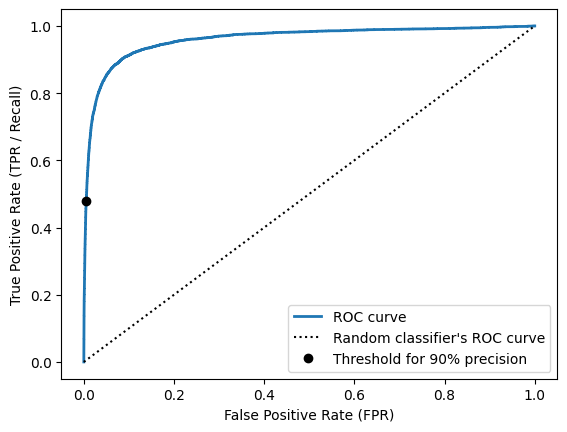

0.9604938554008616


In [ ]:
# The ROC Curve (receiver operating characteristic)
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier

# False Positive Rate (FPR) какую долю настоящих negative объектов модель ошибочно пометила как positive.
# True Positive Rate (TPR) какую долю всех настоящих positive объектов модель смогла правильно найти.
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

# FPR к TPR
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR / Recall)")
plt.legend()
plt.show()
# слева True positive rate (recall)
# снизу false positive rate (fall out)
# Что означает эта точка по смыслу
# при threshold для 90% precision:
## модель:
## находит около 50% настоящих positive (TPR ≈ 0.5)
## ошибочно портит очень мало negative (FPR ≈ 0)
# Идеальная ROC:
# FPR = 0
# TPR = 1
# То есть:
# все positive нашли
# ни одного negative не испортили


# Пунктир ROC-кривую полностью случайного классификатора.
# Хороший классификатор находится как можно дальше 
# от этой линии (в сторону верхнего левого угла).
# Один из способов сравнивать классификаторы — 
# измерять площадь под кривой (AUC).
print(roc_auc_score(y_train_5, y_scores)) # 0.9 модель якобы хорошо отделяет positive от negative классы

# create a RandomForestClassifier, whose PR curve and F1 score we can compare to those of the SGDClassifier:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(random_state=42)
